# Inspecting the full pipeline for the VAE

In [1]:
from __future__ import annotations
import numpy as np 
import matplotlib.pyplot as plt
import json
import os
import sys 
import tskit 
from pathlib import Path
import torch
import yaml 

In [2]:
# Import the YAML 
with open('/sietch_colab/akapoor/PRS_Portability/config_files/model_hyperparams/vae.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [3]:
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
processed_data_path = Path('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0')

In [5]:
# Let's look at the normalized discovery data
norm_discovery_train = np.load(f'{processed_data_path}/discovery_train.npy')
norm_discovery_val = np.load(f'{processed_data_path}/discovery_val.npy')

In [6]:
norm_discovery_train.shape

(4000, 7183)

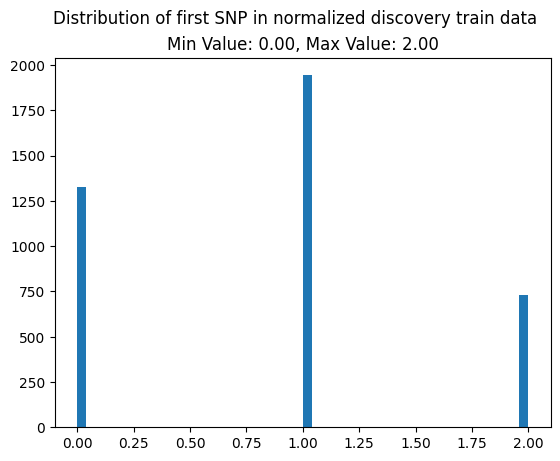

In [7]:
plt.figure()
plt.hist(norm_discovery_train[:,0], bins=50)
plt.suptitle('Distribution of first SNP in normalized discovery train data')
plt.title(f'Min Value: {norm_discovery_train[:,0].min():.2f}, Max Value: {norm_discovery_train[:,0].max():.2f}')
plt.show()

In [8]:
# Print the counts of each unique value across the entire train dataset
unique_all, counts_all = np.unique(norm_discovery_train, return_counts=True)
print(f'TRAINING DATASET')
print(f'Unique values in entire dataset: {unique_all}')
print(f'Counts of unique values in entire dataset: {counts_all}')
print(f'Frequencies of unique values in entire train dataset: {counts_all / norm_discovery_train.size}')
print("=" * 20)
print(f'VALIDATION DATASET')
unique_val, counts_val = np.unique(norm_discovery_val, return_counts=True)
print(f'Unique values in entire dataset: {unique_val}')
print(f'Counts of unique values in entire dataset: {counts_val}')
print(f'Frequencies of unique values in entire validation dataset: {counts_val / norm_discovery_val.size}')

TRAINING DATASET
Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [17049690  7938403  3743907]
Frequencies of unique values in entire train dataset: [0.59340422 0.27629135 0.13030443]
VALIDATION DATASET
Unique values in entire dataset: [0. 1. 2.]
Counts of unique values in entire dataset: [4262364 1983347  937289]
Frequencies of unique values in entire validation dataset: [0.59339607 0.2761168  0.13048712]


## Visualize the mask 

In [9]:
enabled = config['masking']['enabled']
n_blocks = config['masking']['n_blocks']
block_len = config['masking']['block_len']
mask_frac = config['masking']['mask_frac']
allow_overlap = config['masking']['allow_overlap']
seed = config['seed']
fill = config['masking']['fill']
gaussian_std = config['masking']['gaussian_std']
constant_value = config['masking']['constant_value']
constraint_mode = config['masking']['constraint_mode']


In [10]:
from src.masking import make_mask_and_apply
x = torch.tensor(norm_discovery_train[:64], dtype=torch.float32)   # (B, L)

In [11]:
x_in, mask, used_n_blocks, used_block_len, target_mask_frac, realized_mask_frac = make_mask_and_apply(
    x,
    enabled=enabled,
    constraint_mode=constraint_mode,
    n_blocks=n_blocks,
    block_len=block_len,
    mask_frac=mask_frac,
    allow_overlap=allow_overlap,
    seed=seed,
    fill=fill,
    gaussian_std=gaussian_std,
    constant_value=constant_value,
)


print(f'Input shape: {x.shape}')
print(f'Masked input shape: {x_in.shape}')
print(f'Mask shape: {mask.shape}')
print(f'Used n_blocks: {used_n_blocks}')
print(f'Used block length: {used_block_len}')
print(f'Target mask fraction: {target_mask_frac:.4f}')
print(f'Realized mask fraction: {realized_mask_frac:.4f}')

Input shape: torch.Size([64, 7183])
Masked input shape: torch.Size([64, 7183])
Mask shape: torch.Size([64, 7183])
Used n_blocks: 1149
Used block length: 5
Target mask fraction: 0.8000
Realized mask fraction: 0.2622


In [12]:
print(f'Original Input:\n{x}')
print(f'Masked Input:\n{x_in}')
print(f'Mask:\n{mask}')
print()

Original Input:
tensor([[1., 0., 0.,  ..., 0., 0., 1.],
        [1., 1., 0.,  ..., 1., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 1., 0., 1.],
        [0., 1., 0.,  ..., 2., 0., 0.]])
Masked Input:
tensor([[ 1., -1., -1.,  ...,  0.,  0.,  1.],
        [ 1.,  1.,  0.,  ...,  1.,  0.,  1.],
        [ 0.,  0.,  0.,  ..., -1., -1.,  0.],
        ...,
        [ 0.,  1.,  0.,  ...,  0.,  0.,  1.],
        [ 1.,  0.,  0.,  ...,  1.,  0.,  1.],
        [ 0.,  1.,  0.,  ...,  2.,  0.,  0.]])
Mask:
tensor([[False,  True,  True,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])



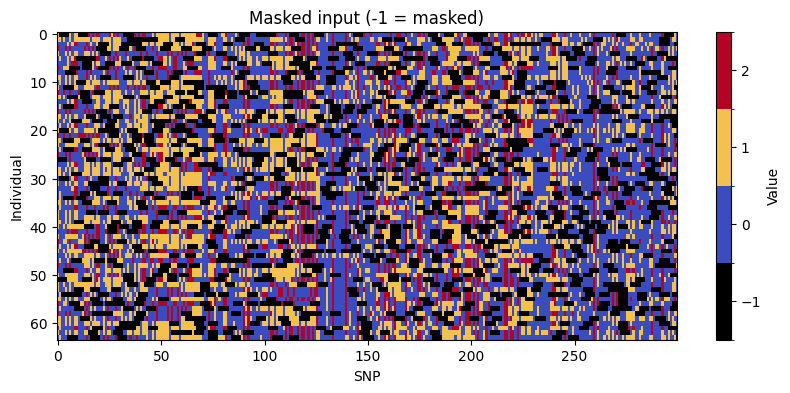

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# discrete colors for values: -1, 0, 1, 2
colors = [
    "black",     # -1 = masked
    "#3b4cc0",   # 0
    "#f2c14e",   # 1
    "#b40426",   # 2
]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 4))

subset = x_in[:, :300].cpu().numpy()   # first 300 SNPs

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[-1, 0, 1, 2])
cbar.set_label("Value")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Masked input (-1 = masked)")
plt.show()

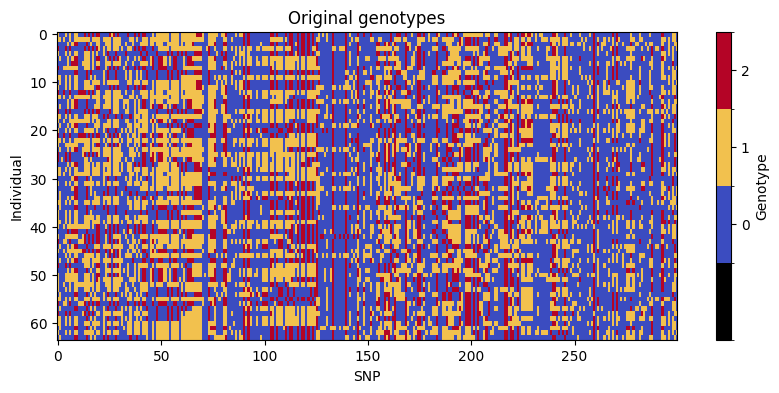

In [14]:
plt.figure(figsize=(10, 4))

subset = x[:, :300].cpu().numpy()

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.set_label("Genotype")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Original genotypes")
plt.show()

In [15]:
## How many values per total SNPs are masked for each individual? 
x_all = torch.tensor(norm_discovery_train, dtype=torch.float32)   # (B, L)
x_in, mask, used_n_blocks, used_block_len, target_mask_frac, realized_mask_frac = make_mask_and_apply(
    x_all,
    enabled=enabled,
    constraint_mode=constraint_mode,
    n_blocks=n_blocks,
    block_len=block_len,
    mask_frac=mask_frac,
    allow_overlap=allow_overlap,
    seed=seed,
    fill=fill,
    gaussian_std=gaussian_std,
    constant_value=constant_value,
)

In [16]:
print("x_all shape:", x_all.shape)
print("masking enabled:", enabled)
print("constraint_mode:", constraint_mode)
print("n_blocks from config:", n_blocks)
print("block_len from config:", block_len)
print("mask_frac from config:", mask_frac)
print("allow_overlap:", allow_overlap)
print("used_n_blocks:", used_n_blocks)
print("used_block_len:", used_block_len)
print("target_mask_frac:", target_mask_frac)
print("realized_mask_frac:", realized_mask_frac)
print("mask sum per sample:", mask.sum(dim=1)[:10])
print("mask frac per sample:", (mask.sum(dim=1).float() / mask.shape[1])[:10])

x_all shape: torch.Size([4000, 7183])
masking enabled: True
constraint_mode: frac_and_len
n_blocks from config: None
block_len from config: 5
mask_frac from config: 0.8
allow_overlap: False
used_n_blocks: 1149
used_block_len: 5
target_mask_frac: 0.8
realized_mask_frac: 0.26214951276779175
mask sum per sample: tensor([1905, 1855, 1860, 1875, 1930, 1910, 1885, 1815, 1870, 1890])
mask frac per sample: tensor([0.2652, 0.2582, 0.2589, 0.2610, 0.2687, 0.2659, 0.2624, 0.2527, 0.2603,
        0.2631])


In [17]:
print("used_block_len:", used_block_len)
print("mask sum per sample:", mask.sum(dim=1)[:10])
print("mask frac per sample:", (mask.sum(dim=1).float() / mask.shape[1])[:10])

used_block_len: 5
mask sum per sample: tensor([1905, 1855, 1860, 1875, 1930, 1910, 1885, 1815, 1870, 1890])
mask frac per sample: tensor([0.2652, 0.2582, 0.2589, 0.2610, 0.2687, 0.2659, 0.2624, 0.2527, 0.2603,
        0.2631])


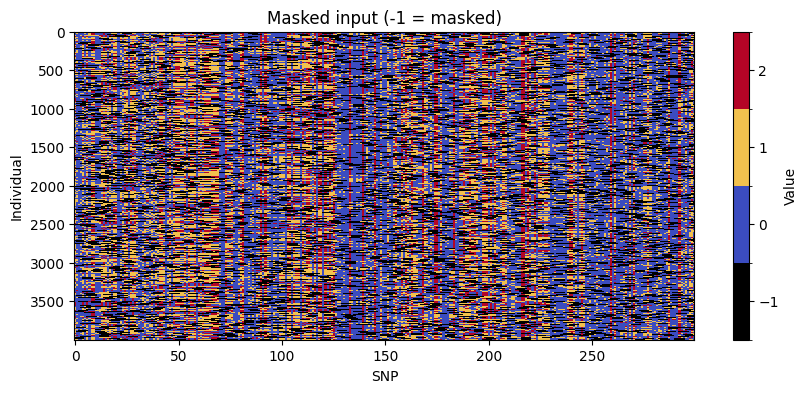

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# discrete colors for values: -1, 0, 1, 2
colors = [
    "black",     # -1 = masked
    "#3b4cc0",   # 0
    "#f2c14e",   # 1
    "#b40426",   # 2
]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 4))

subset = x_in[:, :300].cpu().numpy()   # first 300 SNPs

im = plt.imshow(
    subset,
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

cbar = plt.colorbar(im, ticks=[-1, 0, 1, 2])
cbar.set_label("Value")

plt.xlabel("SNP")
plt.ylabel("Individual")
plt.title("Masked input (-1 = masked)")
plt.show()

In [19]:
num_masked_per_individual = (x_in == constant_value).sum(dim=1)
total_snps = x_in.shape[1]
masking_fraction_per_individual = num_masked_per_individual / total_snps
print(masking_fraction_per_individual)

tensor([0.2652, 0.2582, 0.2589,  ..., 0.2638, 0.2666, 0.2638])


In [20]:
# What are the counts of 0, 1, 2 in the original input that fall within the mask? 
masked_genotypes = x_all[mask == 1]
unique_masked, counts_masked = torch.unique(masked_genotypes, return_counts=True)
print(f'Unique values in masked positions: {unique_masked}')
print(f'Frequencies of unique values in masked positions: {counts_masked / masked_genotypes.numel()}')

Unique values in masked positions: tensor([0., 1., 2.])
Frequencies of unique values in masked positions: tensor([0.5936, 0.2762, 0.1302])


## Investigating the Model

### Initialize the model

In [21]:
import torch
import torch.nn as nn

from src.vae.model import ConvVAE1D, FullyConvVAE1D

# ----------------------------
# choose model + dimensions
# ----------------------------
input_len = 1000
latent_dim = config['model']['latent_dim']
hidden_channels = config['model']['hidden_channels']
kernel_size = config['model']['kernel_size']
stride = config['model']['stride']
padding = config['model']['padding']
use_batchnorm = config['model']['use_batchnorm']
in_channels = 2

model = FullyConvVAE1D(
    input_len=input_len,
    latent_dim=latent_dim,
    hidden_channels=hidden_channels,
    kernel_size=kernel_size,
    stride=stride,
    padding=padding,
    use_batchnorm=use_batchnorm,
    in_channels=in_channels,
)

# Example alternative:
# model = ConvVAE1D(
#     input_len=input_len,
#     latent_dim=latent_dim,
#     hidden_channels=hidden_channels,
#     kernel_size=kernel_size,
#     stride=stride,
#     padding=padding,
#     use_batchnorm=use_batchnorm,
#     in_channels=in_channels,
# )

# ----------------------------
# optional: explicitly reinitialize weights
# ----------------------------
def reinit_weights(m):
    if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm1d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

model.apply(reinit_weights)
model.eval()

print(model)

FullyConvVAE1D(
  (enc_conv): Sequential(
    (0): Conv1d(2, 64, kernel_size=(17,), stride=(2,), padding=(8,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): Conv1d(64, 128, kernel_size=(17,), stride=(2,), padding=(8,))
    (3): ELU(alpha=1.0, inplace=True)
    (4): Conv1d(128, 256, kernel_size=(17,), stride=(2,), padding=(8,))
    (5): ELU(alpha=1.0, inplace=True)
  )
  (conv_mu): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
  (conv_logvar): Conv1d(256, 128, kernel_size=(1,), stride=(1,))
  (dec_proj): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
  (dec_conv): Sequential(
    (0): ConvTranspose1d(256, 128, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): ConvTranspose1d(128, 64, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
    (3): ELU(alpha=1.0, inplace=True)
    (4): ConvTranspose1d(64, 3, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
  )
)


### Pass some random data through the model to see what the shapes look like

In [45]:
import torch

B = 10
C = 2
L = input_len

x = torch.randn(B, C, L)

print("Input shape:", x.shape)

Input shape: torch.Size([10, 2, 1000])


In [ ]:
with torch.no_grad():

    h = x
    print("\n===== ENCODER =====")
    # The stride will reduce the length at each layer 
    

    for i, layer in enumerate(model.enc_conv):
        h = layer(h)
        print(f"enc_conv[{i}] ({layer.__class__.__name__}) -> {h.shape}")


===== ENCODER =====
enc_conv[0] (Conv1d) -> torch.Size([10, 64, 500])
enc_conv[1] (ELU) -> torch.Size([10, 64, 500])
enc_conv[2] (Conv1d) -> torch.Size([10, 128, 250])
enc_conv[3] (ELU) -> torch.Size([10, 128, 250])
enc_conv[4] (Conv1d) -> torch.Size([10, 256, 125])
enc_conv[5] (ELU) -> torch.Size([10, 256, 125])


In [ ]:
with torch.no_grad():
    
    print("\n===== LATENT =====")
    # The convolutions on the latent are acting like linear convolutions on each element (because kernel_size=1 and stride=1), so the length should stay the same and only the channels should change to latent_dim
    mu = model.conv_mu(h)
    print("mu ->", mu.shape)

    logvar = model.conv_logvar(h)
    print("logvar ->", logvar.shape)

    z = model.reparameterize(mu, logvar)
    print("z ->", z.shape)



===== LATENT =====
mu -> torch.Size([10, 128, 125])
logvar -> torch.Size([10, 128, 125])
z -> torch.Size([10, 128, 125])


In [48]:
with torch.no_grad():
    
    print("\n===== DECODER =====")

    h = model.dec_proj(z)
    print("dec_proj ->", h.shape)

    for i, layer in enumerate(model.dec_conv):
        h = layer(h)
        print(f"dec_conv[{i}] ({layer.__class__.__name__}) -> {h.shape}")

    logits = h

    print("\n===== FINAL OUTPUT =====")
    print("logits ->", logits.shape)


===== DECODER =====
dec_proj -> torch.Size([10, 256, 125])
dec_conv[0] (ConvTranspose1d) -> torch.Size([10, 128, 250])
dec_conv[1] (ELU) -> torch.Size([10, 128, 250])
dec_conv[2] (ConvTranspose1d) -> torch.Size([10, 64, 500])
dec_conv[3] (ELU) -> torch.Size([10, 64, 500])
dec_conv[4] (ConvTranspose1d) -> torch.Size([10, 3, 1000])

===== FINAL OUTPUT =====
logits -> torch.Size([10, 3, 1000])


## Investigating model results

In [152]:
import numpy as np
from pathlib import Path

p = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/recon/train_recon.npz")
d = np.load(p)

x_masked = d["x_masked"]
mask = d["mask"]

print("Unique values at masked positions:", np.unique(x_masked[mask])[:20])
print("Min/max at masked positions:", x_masked[mask].min(), x_masked[mask].max())
print("Unique values overall (small sample):", np.unique(x_masked)[:20])

Unique values at masked positions: [-1.]
Min/max at masked positions: -1.0 -1.0
Unique values overall (small sample): [-1.  0.  1.  2.]


In [153]:
list(d.keys())

['x_true',
 'x_masked',
 'mask',
 'recon',
 'pred',
 'prob_0',
 'prob_1',
 'prob_2',
 'used_n_blocks',
 'used_block_len',
 'target_mask_frac',
 'realized_mask_frac']

In [154]:
d['recon']

array([[[-2.71333456e+00,  4.15716171e+00,  5.06166124e+00, ...,
          1.67120838e+00,  4.93113613e+00,  2.74421406e+00],
        [ 3.23492169e+00,  4.17664289e-01,  2.95570350e+00, ...,
          2.13172388e+00,  1.09523535e-05,  1.98919404e+00],
        [ 1.87659359e+00, -9.27178669e+00, -6.12499619e+00, ...,
         -7.53888428e-01, -5.44727325e+00,  7.42702067e-01]],

       [[ 8.48645747e-01,  3.49734402e+00,  9.90865326e+00, ...,
          1.63931513e+00,  3.48910189e+00,  2.92347693e+00],
        [ 4.52173471e+00,  2.49506569e+00,  3.80804944e+00, ...,
          5.16856492e-01,  7.49206185e-01,  2.86958790e+00],
        [ 1.09443164e+00, -6.88943958e+00, -9.69865322e+00, ...,
         -5.44221878e+00, -5.25129890e+00,  7.78243065e-01]],

       [[ 6.99737883e+00,  3.53188419e+00,  4.80575371e+00, ...,
          1.49400890e-01,  4.94049311e+00,  1.44104719e+00],
        [ 3.78753734e+00, -1.31912875e+00,  1.11996007e+00, ...,
         -1.27114192e-01,  1.44353938e+00,  2.102

Confidence Calibration Plot: how confidently did my probabilities assign

In [155]:
def plot_confidence_reliability(npz_path, where="masked_only", n_bins=10):
    data = np.load(npz_path)
    print(data.files)

    x_true = data["x_true"].astype(int)
    mask = data["mask"].astype(bool)
    probs = np.stack([data["prob_0"], data["prob_1"], data["prob_2"]], axis=1)  # (N,3,L)
    probs = probs.transpose(0, 2, 1)  # (N,L,3)

    pred = probs.argmax(axis=-1)
    conf = probs.max(axis=-1)

    if where == "masked_only":
        sel = mask
    elif where == "unmasked_only":
        sel = ~mask
    elif where == "all":
        sel = np.ones_like(mask, dtype=bool)
    else:
        raise ValueError

    y_true = x_true[sel]
    y_pred = pred[sel]
    conf = conf[sel]

    correct = (y_true == y_pred).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(conf, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for b in range(n_bins):
        idx = bin_ids == b
        if idx.sum() == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_count.append(0)
        else:
            bin_acc.append(correct[idx].mean())
            bin_conf.append(conf[idx].mean())
            bin_count.append(idx.sum())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
    plt.plot(bin_conf, bin_acc, marker="o", label="model")
    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Empirical accuracy")
    plt.title(f"Reliability plot: {Path(npz_path).name} [{where}]")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print("Bin counts:", bin_count)

['x_true', 'x_masked', 'mask', 'recon', 'pred', 'prob_0', 'prob_1', 'prob_2', 'used_n_blocks', 'used_block_len', 'target_mask_frac', 'realized_mask_frac']


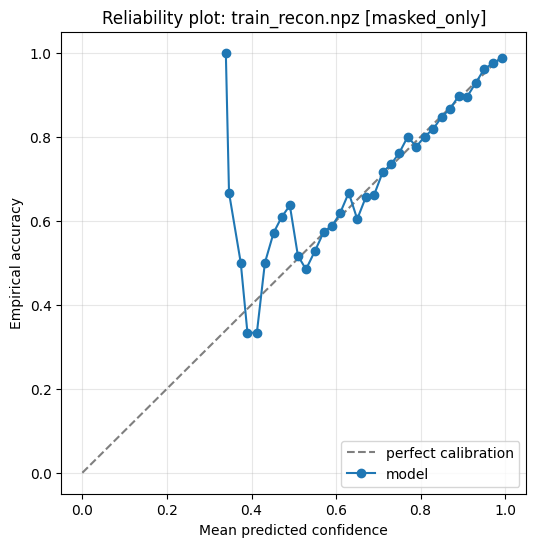

Bin counts: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.int64(1), np.int64(3), np.int64(4), np.int64(3), np.int64(12), np.int64(10), np.int64(21), np.int64(23), np.int64(66), np.int64(118), np.int64(95), np.int64(121), np.int64(124), np.int64(114), np.int64(136), np.int64(87), np.int64(106), np.int64(122), np.int64(133), np.int64(123), np.int64(132), np.int64(143), np.int64(135), np.int64(161), np.int64(175), np.int64(182), np.int64(190), np.int64(180), np.int64(206), np.int64(259), np.int64(333), np.int64(389), np.int64(585), np.int64(1268)]
['x_true', 'x_masked', 'mask', 'recon', 'pred', 'prob_0', 'prob_1', 'prob_2', 'used_n_blocks', 'used_block_len', 'target_mask_frac', 'realized_mask_frac']


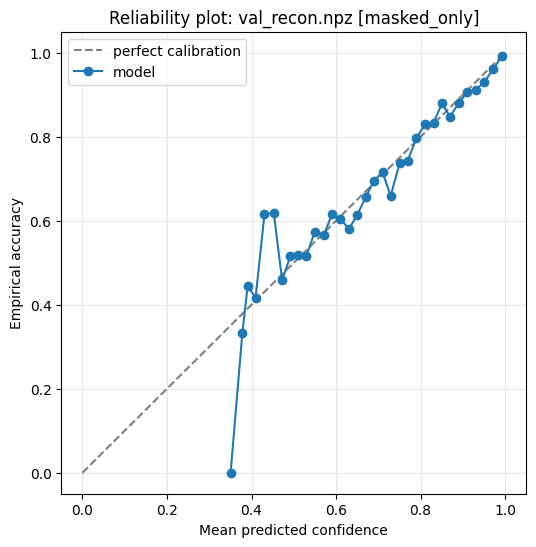

Bin counts: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, np.int64(2), np.int64(3), np.int64(9), np.int64(12), np.int64(13), np.int64(21), np.int64(24), np.int64(64), np.int64(106), np.int64(101), np.int64(108), np.int64(99), np.int64(130), np.int64(111), np.int64(136), np.int64(111), np.int64(134), np.int64(138), np.int64(123), np.int64(129), np.int64(148), np.int64(140), np.int64(142), np.int64(153), np.int64(174), np.int64(166), np.int64(210), np.int64(201), np.int64(254), np.int64(319), np.int64(396), np.int64(581), np.int64(1302)]


In [156]:
# Training
plot_confidence_reliability(p, where="masked_only", n_bins=50)

# Validation
p_val = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/recon/val_recon.npz")
plot_confidence_reliability(p_val, where="masked_only", n_bins=50)

                  experiment param_name  param_value  val_balanced_accuracy
2    vae_maskfrac__blocklen5   blocklen            5                 0.7392
0  vae_maskfrac__blocklen100   blocklen          100                 0.3597
1  vae_maskfrac__blocklen200   blocklen          200                 0.3400


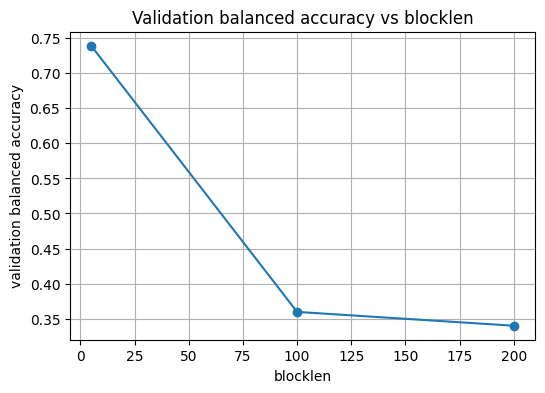

In [4]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# base = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/varying_mask_fraction")
# base = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/varying_latent_dim")
base = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/varying_blocklen")

rows = []

def parse_experiment_value(dirname: str):
    """
    Extract the final varying parameter from names like:
      vae_maskfrac__maskfrac0p4
      vae_maskfrac__latdim128

    Returns:
      param_name, numeric_value
    """
    last_token = dirname.split("__")[-1]   # e.g. "maskfrac0p4" or "latdim128"

    m = re.match(r"([a-zA-Z_]+)([0-9p.]+)", last_token)
    if not m:
        raise ValueError(f"Could not parse experiment directory name: {dirname}")

    param_name = m.group(1)
    value_str = m.group(2).replace("p", ".")
    value = float(value_str)

    # convert things like 128.0 -> 128 when appropriate
    if value.is_integer():
        value = int(value)

    return param_name, value


for exp_dir in sorted(base.iterdir()):
    if not exp_dir.is_dir():
        continue

    try:
        param_name, param_value = parse_experiment_value(exp_dir.name)
    except ValueError as e:
        print(e)
        continue

    summary = exp_dir / "0/rep0/diagnostics/balanced_accuracy_summary.txt"

    if not summary.exists():
        print(f"Missing: {summary}")
        continue

    with open(summary) as f:
        for line in f:
            if line.startswith("val:"):
                m = re.search(r"bal_acc_masked=([0-9.]+)", line)
                if m:
                    rows.append({
                        "experiment": exp_dir.name,
                        "param_name": param_name,
                        "param_value": param_value,
                        "val_balanced_accuracy": float(m.group(1)),
                    })

df = pd.DataFrame(rows)

if df.empty:
    print("No rows found. Check base path and summary file locations.")
else:
    df = df.sort_values("param_value")
    print(df)

    x_label = df["param_name"].iloc[0]

    plt.figure(figsize=(6, 4))
    plt.plot(df["param_value"], df["val_balanced_accuracy"], marker="o")
    plt.xlabel(x_label)
    plt.ylabel("validation balanced accuracy")
    plt.title(f"Validation balanced accuracy vs {x_label}")
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np 
a = np.load('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/masked_inputs/train_mask_epoch0.npy')